In [1]:
#!/usr/bin/env python3
# train_FG_long_k.py
# Convert wide (ETA, F1..F12, G1..G12) -> long dataset with mapping k->(Ri,M)
# Train NN to predict (Fval,Gval) from inputs (Ri, M, Eta, k).
# Optional: you can later extend pde_residuals(...) and set USE_PDE=True for PINN.

import os, time, json
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------------- User settings ----------------
DATA_PATH = "Grad-4-Merged.csv"   # your CSV
OUT_DIR = "pinn_fg_long_out_4-3h"  # output dir for models, plots, etc.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# mapping k -> (Epsilon, N) as you described
Cf_map = {
    1: (0, 10), 2: (0.1, 10), 3: (0.3, 10),
    4: (0.5, 10)
}

# training hyperparams (tune)
SEED = 42
N_EPOCHS = 1600
BATCH_SIZE = 128
LR = 2e-3
ONECYCLE_MAX_LR = 8e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 300
PRINT_EVERY = 80

USE_PDE = False   # set True only after you implement pde_residuals()
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)

# ---------------- Load CSV and build long dataset ----------------
df_w = pd.read_csv(DATA_PATH)
print("Loaded CSV:", DATA_PATH, "shape:", df_w.shape)
print("Columns:", df_w.columns.tolist()[:20])

# find ETA column
eta_col = next((c for c in df_w.columns if c.strip().lower()=='eta' or 'eta' in c.lower()), None)
if eta_col is None:
    raise RuntimeError("ETA column not found in CSV.")

# check F/G columns exist
Cf_cols = [f"Cf{i}" for i in range(1,5)]
#G_cols = [f"G{i}" for i in range(1,13)]
for c in Cf_cols:
    if c not in df_w.columns:
        raise RuntimeError(f"Column {c} not found in CSV.")

# Build long records: for each k create rows with assigned Ri,M
records = []
n_eta = df_w.shape[0]
for k in range(1,5):
    epsilon, n = Cf_map[k]
    Cf_col = f"Cf{k}"
    for i in range(n_eta):
        records.append({
            "Epsilon": epsilon,
            "N": n,
            "Eta": float(df_w.iloc[i][eta_col]),
            "k": float(k),           # include k as numeric (we'll normalize)
            "Cf_val": float(df_w.iloc[i][Cf_col]),
            #"Gval": float(df_w.iloc[i][Gcol])
        })
df = pd.DataFrame.from_records(records)
print("Built long dataframe shape:", df.shape)
df.to_csv(os.path.join(OUT_DIR,"Cf_long_raw.csv"), index=False)



Loaded CSV: Grad-4-Merged.csv shape: (252, 5)
Columns: ['ETA', 'Cf1', 'Cf2', 'Cf3', 'Cf4']
Built long dataframe shape: (1008, 5)


In [2]:
# ---------------- Attention-based model (replace previous broken MHA usage) ----------------
import os, time, json
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------- fallback defaults (only used if not defined earlier) ----------
try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    OUT_DIR
except NameError:
    OUT_DIR = "pinn_fg_long_out_attn"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = globals().get("SEED", 42)
N_EPOCHS = globals().get("N_EPOCHS", 1600)
BATCH_SIZE = globals().get("BATCH_SIZE", 128)
LR = globals().get("LR", 2e-3)
ONECYCLE_MAX_LR = globals().get("ONECYCLE_MAX_LR", 8e-3)
GRAD_CLIP = globals().get("GRAD_CLIP", 5.0)
LBFGS_ITERS = globals().get("LBFGS_ITERS", 200)
EARLY_STOPPING_PATIENCE = globals().get("EARLY_STOPPING_PATIENCE", 300)
PRINT_EVERY = globals().get("PRINT_EVERY", 80)

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- Prepare model inputs/outputs (rebuild to be self-contained) ----------------
# expects df with columns Epsilon,N,Eta,k,Cf_val
assert all(c in df.columns for c in ["Epsilon","N","Eta","Cf_val"]), "df must contain Epsilon,N,Eta,Cf_val"

X = df[["Epsilon","N","Eta"]].values.astype(np.float32)
Y = df[["Cf_val"]].values.astype(np.float32)

# Normalize inputs and target per-column
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# train/val/test split stratified by Ri_M combos
df["combo"] = df["Epsilon"].astype(str) + "_" + df["N"].astype(str)
idxs = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idxs, test_size=0.18, random_state=SEED, stratify=df['combo'])
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_all   = Xn.copy()

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], Xn.shape[0]-X_train.shape[0]-X_val.shape[0])

# convert to torch tensors
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(X_all, dtype=torch.float32, device=device)
Yn_t      = torch.tensor(Yn, dtype=torch.float32, device=device)

# ---------------- Attention model components ----------------
class Tokenizer(nn.Module):
    """Project 3 scalar inputs into 3 token embeddings (N, seq=3, token_dim)"""
    def __init__(self, token_dim=64):
        super().__init__()
        self.embed_epsilon  = nn.Linear(1, token_dim)
        self.embed_N   = nn.Linear(1, token_dim)
        self.embed_Eta = nn.Linear(1, token_dim)
        self.act = nn.SiLU()
    def forward(self, x):
        # x: (N,3) order [Epsilon,N,Eta]
        Epsilon  = self.act(self.embed_epsilon(x[:,0:1]))
        N   = self.act(self.embed_N(x[:,1:2]))
        Eta = self.act(self.embed_Eta(x[:,2:3]))
        tokens = torch.stack([Epsilon, N, Eta], dim=1)   # (N,3,token_dim)
        return tokens

class AttentionBlock(nn.Module):
    """Attention block with residuals + deeper 3-layer FFN"""
    def __init__(self, token_dim=256, num_heads=3, ff_mult=8, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=token_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(token_dim)

        hidden1 = token_dim * ff_mult
        hidden2 = token_dim * ff_mult
        hidden3 = token_dim * ff_mult

        self.ff = nn.Sequential(
            nn.Linear(token_dim, hidden1),
            nn.SiLU(),
            nn.Linear(hidden1, hidden2),
            nn.SiLU(),
            nn.Linear(hidden2, hidden3),
            nn.SiLU(),
            nn.Linear(hidden3, token_dim)
        )

        self.ln2 = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tokens):
        attn_out, _ = self.mha(tokens, tokens, tokens)
        x = self.ln1(tokens + self.dropout(attn_out))
        ff_out = self.ff(x)
        out = self.ln2(x + self.dropout(ff_out))
        return out

class AttentionPINN(nn.Module):
    def __init__(self, token_dim=256, num_heads=3, n_blocks=3, out_dim=1):
        super().__init__()
        self.tokenizer = Tokenizer(token_dim=token_dim)
        self.pos_emb = nn.Parameter(torch.randn(1, 3, token_dim) * 0.01)
        self.blocks = nn.ModuleList([AttentionBlock(token_dim=token_dim, num_heads=num_heads) for _ in range(n_blocks)])
        # pooling + head
        self.pool = nn.Sequential(
            nn.Flatten(),                      # (N, 3*token_dim)
            nn.Linear(3*token_dim, token_dim),
            nn.SiLU(),
            nn.Linear(token_dim, out_dim)
        )
        # init
        for p in self.modules():
            if isinstance(p, nn.Linear):
                nn.init.xavier_uniform_(p.weight); 
                if p.bias is not None: nn.init.zeros_(p.bias)
    def forward(self, x):
        # x: (N,3)
        tokens = self.tokenizer(x) + self.pos_emb   # (N,4,token_dim)
        for blk in self.blocks:
            tokens = blk(tokens)
        out = self.pool(tokens)   # (N, out_dim)
        return out

# ---------------- Instantiate model ----------------
model = AttentionPINN(token_dim=128, num_heads=4, n_blocks=3, out_dim=1).to(device)
print("Model params:", sum(p.numel() for p in model.parameters()))

# ---------------- Optimizer + Scheduler ----------------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
steps_per_epoch = max(1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE))))
total_steps = N_EPOCHS * steps_per_epoch
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=ONECYCLE_MAX_LR,
                                          total_steps=total_steps, pct_start=0.1, div_factor=10.0)
mse = nn.MSELoss()

# ---------------- Training loop ----------------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    losses = []
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device)
        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)
        optimizer.zero_grad()
        pred = model(xb)                     # (batch,1)
        loss = mse(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    model.eval()
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device))
        val_loss = float(mse(val_pred, torch.tensor(Y_val, dtype=torch.float32, device=device)).item())

    history['train'].append(train_loss); history['val'].append(val_loss)
    if ep % PRINT_EVERY == 0 or ep==1:
        print(f"Epoch {ep}/{N_EPOCHS}  train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_attn.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep); break

t1 = time.time()
print("Training finished in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))
# load best
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_attn.pt"), map_location=device))
model.eval()

# ---------------- LBFGS refinement (optional) ----------------
print("LBFGS refine (optional)...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, Yn_t)
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()   # normalized predictions
Ypred = Ypred_n * Y_std + Y_mean            # invert normalization (original scale)

# attach predictions to df and save
df['p_Cf_val'] = Ypred[:,0]
out_csv = os.path.join(OUT_DIR, "Cf_long_preds_attn.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# save training history and norm params
np.savez(os.path.join(OUT_DIR,"norm_params_attn.npz"), X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std)
with open(os.path.join(OUT_DIR,"history_attn.json"), "w") as f:
    json.dump(history, f)

print("Done. Results saved in:", OUT_DIR)


Train/Val/Test sizes: 826 91 91
Model params: 7337729
Epoch 1/1600  train=5.692e+00 val=1.263e+00 lr=8.01e-04
Epoch 80/1600  train=1.006e+00 val=9.164e-01 lr=4.41e-03
Epoch 160/1600  train=1.004e+00 val=9.149e-01 lr=8.00e-03
Epoch 240/1600  train=1.068e+00 val=9.154e-01 lr=7.94e-03
Epoch 320/1600  train=1.008e+00 val=9.150e-01 lr=7.76e-03
Early stopping at epoch 350
Training finished in 3664.6s best_val=5.0780e-01
LBFGS refine (optional)...
Saved long-format predictions to: pinn_fg_long_out_4-3h\Cf_long_preds_attn.csv
Done. Results saved in: pinn_fg_long_out_4-3h


In [3]:
# Compute RMSE overall and per combo and per k
df['err_Cf2'] = (df['p_Cf_val'] - df['Cf_val'])**2

rmse_overall = np.sqrt(df[['err_Cf2']].mean(axis=0))
print("Overall RMSE (Cf):", rmse_overall.tolist())

# per k RMSE
rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))

rmse_df = pd.DataFrame({'k': rmse_k.index, 'rmse_F': rmse_k.values})
rmse_df.to_csv(os.path.join(OUT_DIR,"rmse_per_k.csv"), index=False)
print("Saved rmse_per_k.csv")

# ---------------- plots: reconstruct curves per k (Ri,M) ----------------
for k in sorted(df['k'].unique()):
    sub = df[df['k']==k].sort_values('Eta')
    epsilon,n = Cf_map[int(k)]
    plt.figure(figsize=(8,6))
    plt.plot(sub['Eta'], sub['Cf_val'], '-', label='Cf true')
    plt.plot(sub['Eta'], sub['p_Cf_val'], '--', label='Cf pred')
    
    plt.title(f"k={int(k)} Epsilon={epsilon} N={n}")
    plt.legend()
    plt.xlabel("Eta")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"curve_k{k}_Epsilon{epsilon}_N{n}.png"))
    plt.close()

print("Saved curve plots and parity/rmse info in", OUT_DIR)

Overall RMSE (Cf): [58.00218201094811]
Saved rmse_per_k.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_22356\1328677935.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_k = df.groupby('k').apply(lambda g: np.sqrt(np.mean((g['p_Cf_val']-g['Cf_val'])**2)))


Saved curve plots and parity/rmse info in pinn_fg_long_out_4-3h


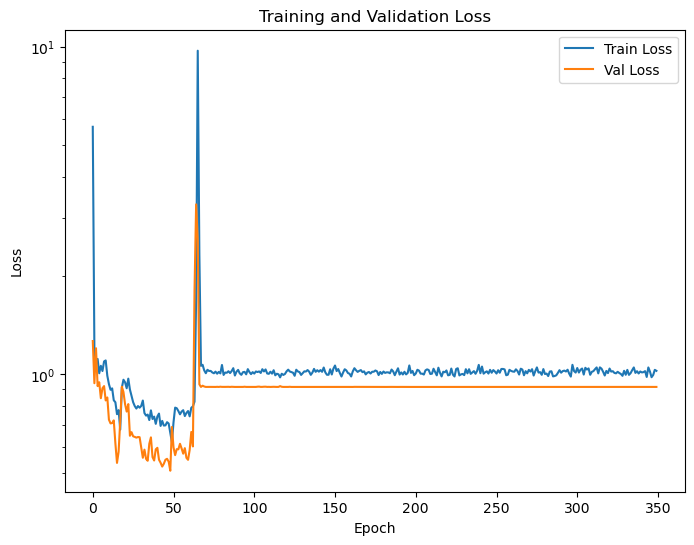

In [4]:
#Plot the training history
plt.figure(figsize=(8,6))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [6]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,5):
    sub = df[df['k']==k].sort_values('Eta')
    epsilon, n = Cf_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Cf_val'], mode='lines', name=f'Cf true  Epsilon={epsilon} N={n}'))
    
fig.update_layout(title='F and G values vs Eta for different k, Epsilon, N', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "Cf_values_plotly.html"))
fig.show()

In [7]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,5):
    sub = df[df['k']==k].sort_values('Eta')
    epsilon, n = Cf_map[int(k)]
    
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Cf_val'], mode='lines', name=f'Cf pred  Epsilon={epsilon} N={n}'))
    
fig.update_layout(title='Cf values vs Eta for different k, Epsilon, N', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_Pred_values_plotly.html"))
fig.show()

In [8]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,5):
    sub = df[df['k']==k].sort_values('Eta')
    epsilon, n = Cf_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Cf_val'], mode='markers', name=f'F true  Epsilon={epsilon} N={n}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Cf_val'], mode='lines', name=f'F pred  Epsilon={epsilon} N={n}'))
    
fig.update_layout(title='F and G values vs Eta for different k, Epsilon, N', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_F-Pred_values_plotly.html"))
fig.show()